# Physics-Conforming Latent Twins: A Minimal Worked Example

This notebook presents a minimal, runnable introduction to the **Physics-Conforming Latent Twin** framework using the undamped pendulum as a simple test problem. The goal is to walk through the full workflow in one place: generating trajectory data, forming training pairs, defining the Latent Twin model, training the surrogate, and evaluating extrapolation and energy drift.

This version of the tutorial uses **both** physics-conforming mechanisms introduced in the paper (1) decoder-pullback matching and  (2) latent conformity and compares the baseline **Latent Twin** against the **Physics-Conforming Latent Twin** trained with both conformity losses switched on.

The example is intentionally lightweight and is designed to run in well under five minutes on a standard laptop CPU. It focuses on the core ideas rather than the full experimental machinery. For the complete pipeline used in the paper — including additional ODE and PDE benchmarks, hard-constrained Hamiltonian architectures, PINN baselines, and ablation studies — see the accompanying GitHub repository.

**Outline**

1. The pendulum system and its conserved energy
2. Construction of training pairs $(x_s,s)$ and $(x_t,t)$
3. The Latent Twin architecture
4. The training objective: decoder-pullback and latent conformity losses
5. Model training: Latent Twin vs. Physics-Conforming Latent Twin
6. Evaluation: extrapolation accuracy and energy drift


## 1. The physical system: an undamped pendulum

We use $x = (\theta, \omega)$ to denote the pendulum's angle and angular velocity. In this example, the state is finite-dimensional, so $x$ is exactly the quantity observed by the learning algorithm. The undamped pendulum obeys
$$
\theta' = \omega, \qquad \omega' = -\frac{g}{l}\sin\theta,
$$

with $l = 1$, $g = 9.8$, and initial state $(\theta, \omega) = (\pi/4, 0)$.


This is a conservative **Hamiltonian** system: the total mechanical energy

$$
H(\theta,\omega) = \frac12\,\omega^2 + \frac{g}{l}\bigl(1-\cos\theta\bigr)
$$

is conserved exactly along any true trajectory. 


Since the pendulum conserves a nonlinear Hamiltonian, it provides a more challenging test problem than systems with linear or quadratic conserved quantities. To achieve accurate extrapolation beyond the training interval, the model must learn not only the dynamics but also the structure associated with the conserved energy.

We will generate one ground-truth trajectory on $[0, T_{\text{ext}}]$ with
`scipy.integrate.odeint`, train the Latent Twin using only data from
$t \in [0, T_{\text{end}}]$, and then check whether it well extrapolates beyond
$T_{\text{end}}$, where $T_{\text{end}} < T_{\text{ext}}$.


In [18]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # avoid an OpenMP duplicate-runtime hang when
                                               # numpy/torch/scipy all link their own copy
import warnings
warnings.filterwarnings("ignore")             # silence unrelated library deprecation noise

import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import odeint
import matplotlib.pyplot as plt

torch.manual_seed(0)

# ── ODE system: undamped pendulum ─────────────────────────────────────────
gravity = 9.8
x0 = [np.pi / 4, 0.0]   # theta, omega
nState = len(x0)        # dimension of the physical state x


def pendulum(state, t):
    theta, omega = state
    return [omega, -gravity * np.sin(theta)]


def physicalEnergy(state):
    # physical invariant: total mechanical energy H(theta, omega)
    theta, omega = state[:, 0], state[:, 1]
    return 0.5 * omega ** 2 + gravity * (1 - torch.cos(theta))


odeFunction = pendulum

### Generate the ground-truth trajectory and plot it

We integrate the pendulum once over $[0, T_{\text{ext}}]$ with
$T_{\text{ext}} > T_{\text{end}}$, so the same trajectory provides both the training
data (everything with $t \le T_{\text{end}}$) and a held-out region we can use to test
extrapolation later. The shaded region below marks the training horizon
$[0, T_{\text{end}}]$.


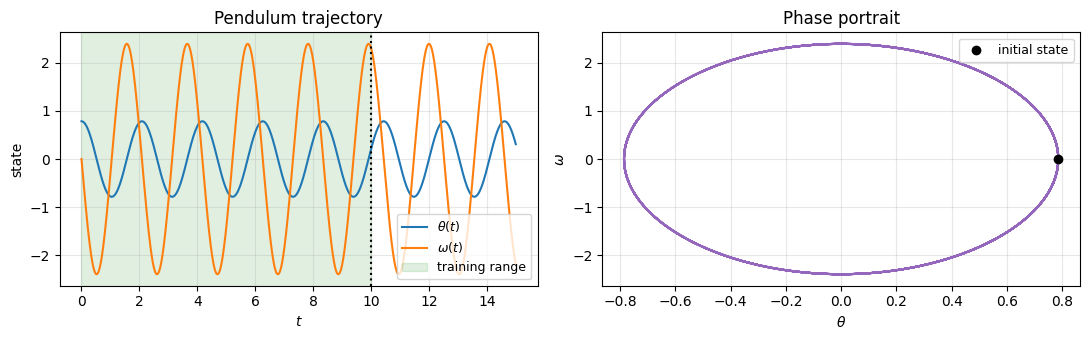

Hamiltonian H(t): mean = 2.870354, std = 4.90e-07  (should be ~constant)


In [19]:
tEnd    = 10.0   # training horizon; pairs are only sampled from t <= tEnd
tExt    = 15.0   # integration time for generating data; the plot also shows t > tEnd
nPoints = 2000   # number of time points for generating data


def generateData():
    T = np.linspace(0.0, tExt, nPoints)
    X = odeint(odeFunction, x0, T)
    return torch.tensor(T, dtype=torch.float32), torch.tensor(X, dtype=torch.float32)


T, X = generateData()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(T, X[:, 0], label=r"$\theta(t)$", color="tab:blue")
axes[0].plot(T, X[:, 1], label=r"$\omega(t)$", color="tab:orange")
axes[0].axvspan(0, tEnd, color="green", alpha=0.12, label="training range")
axes[0].axvline(tEnd, color="k", ls=":", lw=1.5)
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("state")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_title("Pendulum trajectory")

axes[1].plot(X[:, 0], X[:, 1], color="tab:purple", lw=1.5)
axes[1].scatter([X[0, 0]], [X[0, 1]], color="black", zorder=5, label="initial state")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$\omega$")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_title("Phase portrait")

plt.tight_layout(); plt.show()

H = physicalEnergy(X)
print(f"Hamiltonian H(t): mean = {H.mean():.6f}, std = {H.std():.2e}  (should be ~constant)")

## 2. Training pairs $(x_s, s), (x_t, t)$

Latent Twins are trained on *pairs* of states drawn from the same
trajectory, not on the trajectory as a sequence. Given trajectories of a
dynamical system, we form training pairs

$$
\bigl\{ (x_s^j, s^j),\, (x_t^j, t^j) \bigr\}_{j=1}^J ,
$$

where $x_s^j$ and $x_t^j$ are states from the same trajectory evaluated at
two time points $s^j, t^j \in [0, T_{\text{end}}]$. The time pairs are sampled
uniformly from the training interval (other sampling strategies are
possible). 
Each pair describes how the system evolves from a source state at time $s$ to a target state at time $t$. Because the model is trained on many such source-target pairs with varying time gaps, it can learn dynamics over arbitrary time intervals $\Delta t = t-s$.

Below we draw $J = 2^{12}$ such pairs and visualize a handful of them as line
segments connecting a source point $(s, \theta(s))$ to its paired target
point $(t, \theta(t))$.


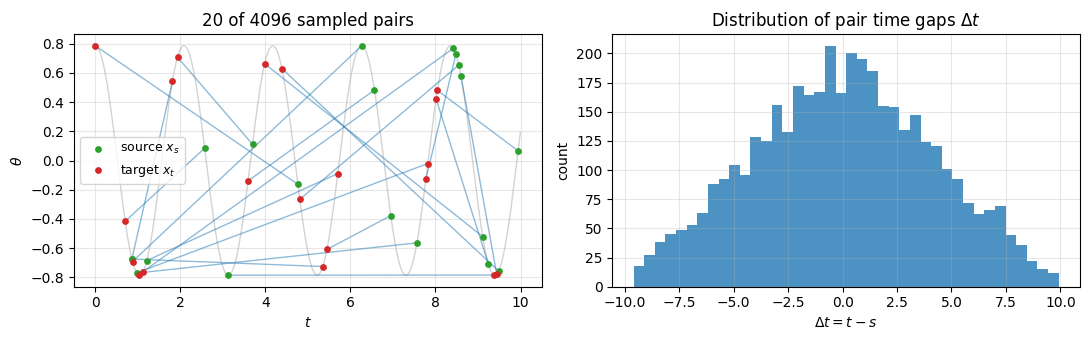

J = 4096 pairs sampled uniformly from t, s in [0, 10.0]


In [20]:
nPairs = 2 ** 12   # number of (s, t) pairs to sample for latent twin training


def samplePairs(T, X, n):
    idx = T <= tEnd
    t, x = T[idx], X[idx]
    sIdx = torch.randint(0, len(t), (n,))
    tIdx = torch.randint(0, len(t), (n,))
    return t[sIdx], x[sIdx], t[tIdx], x[tIdx]


sTime, xs, tTime, xt = samplePairs(T, X, nPairs)
deltaTime = tTime - sTime

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# a random subsample of pairs, drawn as source -> target segments over theta(t)
idx = T <= tEnd
axes[0].plot(T[idx], X[idx, 0], color="lightgray", lw=1, zorder=1)
showIdx = torch.randperm(nPairs)[:20]
for i in showIdx:
    axes[0].plot([sTime[i], tTime[i]], [xs[i, 0], xt[i, 0]],
                 color="tab:blue", alpha=0.5, lw=1, zorder=2)
axes[0].scatter(sTime[showIdx], xs[showIdx, 0], color="tab:green", s=15, zorder=3, label="source $x_s$")
axes[0].scatter(tTime[showIdx], xt[showIdx, 0], color="tab:red", s=15, zorder=3, label="target $x_t$")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$\theta$")
axes[0].set_title(f"20 of {nPairs} sampled pairs")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(deltaTime.numpy(), bins=40, color="tab:blue", alpha=0.8)
axes[1].set_xlabel(r"$\Delta t = t - s$"); axes[1].set_ylabel("count")
axes[1].set_title(r"Distribution of pair time gaps $\Delta t$")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"J = {nPairs} pairs sampled uniformly from t, s in [0, {tEnd}]")

## 3. The Latent Twin architecture

The Latent Twin couples an encoder/decoder pair with a latent
time-evolution operator, learned jointly:

* an encoder $e_\theta : x \mapsto z$ mapping the physical state into a
  latent space,
* a decoder $d_\theta : z \mapsto x$ mapping back,
* a latent flow $m_{\theta, s\to t}$ that advances a latent state from time
  $s$ to time $t$.

Here we use the simplest possible latent flow: a **linear** generator $W$,
whose exact flow is the matrix exponential

$$
z_t = m_{\theta, s\to t}(z_s) = \exp\bigl((t-s)\,W\bigr)\, z_s .
$$

Composing these gives the model's two outputs of interest: the
autoencoder reconstruction $d_\theta(e_\theta(x_s))$, and the
source-to-target prediction $d_\theta\bigl(m_{\theta,s\to t}(e_\theta(x_s))\bigr)$.

In this minimal version $W$ is an **unconstrained** trainable matrix — the
encoder, decoder, and $W$ are all learned purely from the $(x_s,s),(x_t,t)$
pairs, with no access to the pendulum ODE itself. The only physics that
enters is through the optional conformity regularizers described in the next section.


In [22]:
nHidden = [16, 6]   # encoder layer widths; last entry is the latent dimension


def buildMLP(dims):
    layers = []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1]))
        if i < len(dims) - 2:
            layers.append(nn.Tanh())
    return nn.Sequential(*layers)


def matrixExpFlow(W, z, s, t):
    """Exact solution of dz/dt = W z: z(t) = exp((t - s) * W) z(s)."""
    deltaTime = t - s
    A = deltaTime.view(-1, 1, 1) * W.unsqueeze(0)
    expA = torch.linalg.matrix_exp(A)
    return torch.bmm(expA, z.unsqueeze(-1)).squeeze(-1)


class LatentTwin(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = buildMLP([nState, *nHidden])         # encoder: state -> latent
        self.d = buildMLP([*nHidden[::-1], nState])    # decoder: latent -> state
        self.A = nn.Parameter(0.01 * torch.randn(nHidden[-1], nHidden[-1]))  # latent generator

    @property
    def W(self):
        # Free (unconstrained) latent generator -- no stability guarantee.
        return self.A

    def forward(self, xs, s, t):
        zs = self.e(xs)                       # encode source state
        zt = matrixExpFlow(self.W, zs, s, t)   # exact latent flow, source -> target
        xtHat = self.d(zt)                     # decoded prediction of x_t
        xsTilde = self.d(zs)                   # autoencoder reconstruction of x_s
        return xtHat, zs, zt, xsTilde


model = LatentTwin()
print(model)

nParams = sum(p.numel() for p in model.parameters())
print(f"\nstate dim n      = {nState}")
print(f"latent dim n_z   = {nHidden[-1]}")
print(f"hidden widths    = {nHidden[:-1]}")
print(f"trainable params = {nParams}")

LatentTwin(
  (e): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=6, bias=True)
  )
  (d): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)

state dim n      = 2
latent dim n_z   = 6
hidden widths    = [16]
trainable params = 332


## 4. The training objective

Following the general Latent Twin setup, the total empirical loss combines
an autoencoder reconstruction loss, a prediction loss, and a conformity
loss:

$$
\mathcal L_{\mathrm{total}}(\theta)
 = \lambda_{\mathrm{auto}}\,\mathcal L_{\mathrm{auto}}(\theta)
 + \lambda_{\mathrm{pred}}\,\mathcal L_{\mathrm{pred}}(\theta)
 + \mathcal L_{\mathrm{conf}}(\theta).
$$

The first two terms are squared $\ell^2$ losses over the $J$ training pairs:

$$
\mathcal L_{\mathrm{auto}}(\theta)
 = \tfrac{1}{2J}\sum_{j=1}^J \bigl\|d_\theta(e_\theta(x_s^j)) - x_s^j\bigr\|^2
 + \tfrac{1}{2J}\sum_{j=1}^J \bigl\|d_\theta(e_\theta(x_t^j)) - x_t^j\bigr\|^2,
$$

$$
\mathcal L_{\mathrm{pred}}(\theta)
 = \tfrac{1}{J}\sum_{j=1}^J \bigl\|d_\theta\bigl(m_{\theta,s^j\to t^j}(e_\theta(x_s^j))\bigr) - x_t^j\bigr\|^2 .
$$

We set $\lambda_{\mathrm{auto}} = \lambda_{\mathrm{pred}} = 1$.

Here we use **both** physics-conforming mechanisms
from the paper (1) matching the decoder-induced pullback, and  (2) enforcing
conformity of the latent evolution itself -- combined as

$$
\mathcal L_{\mathrm{conf}}(\theta)
 = \lambda_{\mathrm{pullback}}\,\mathcal L_{\mathrm{pullback}}(\theta)
 + \lambda_{\mathrm{latent}}\,\mathcal L_{\mathrm{latent}}(\theta).
$$

For both terms, we use the quadratic latent energy
$$
C_Z(z) = \tfrac12\,z^\top Q_Z z, \qquad Q_Z = I \ \Rightarrow\ C_Z(z) = \tfrac12\|z\|^2,
$$
as a simple latent analogue of the physical Hamiltonian $C = H$.

### Decoder-pullback conformity

*Pullback matching* encourages $C_Z$ to align with the decoder-induced
physical quantity $C \circ d_\theta$ on encoded states:

$$
\mathcal L_{\mathrm{pullback}}(\theta)
 = \tfrac1J\sum_{j=1}^J \bigl\| C_Z(e_\theta(x_s^j)) - C(d_\theta(e_\theta(x_s^j))) \bigr\|^2 .
$$

This term connects the latent functional to the *decoded* physical energy,
but says nothing about how $C_Z$ itself evolves under the latent flow.

### Latent conformity

*Latent conformity* instead constrains $C_Z$ directly along the learned
dynamics. Since the pendulum's energy is exactly conserved (an
equality-type constraint), we use

$$
\mathcal L_{\mathrm{latent}}(\theta)
 = \tfrac1J \sum_{j=1}^J \bigl\| C_Z\bigl(m_{\theta,s^j\to t^j}(e_\theta(x_s^j))\bigr) - C_Z(e_\theta(x_s^j)) \bigr\|^2 ,
$$

which penalizes any change of the latent energy as $z_s = e_\theta(x_s^j)$
is advanced to $z_t = m_{\theta,s^j\to t^j}(z_s)$ by the latent flow. Unlike
the pullback term, this loss acts purely on the latent dynamics and does
not involve the decoder.

Both terms are **soft** constraints: they encourage, but do not guarantee,
that the learned latent generator $W$ respects the pendulum's energy
structure. Setting $\lambda_{\mathrm{pullback}} = \lambda_{\mathrm{latent}} = 0$
recovers the plain **Latent Twin**; below we compare it against the
**Physics-Conforming Latent Twin** trained with $\lambda_{\mathrm{pullback}} =
\lambda_{\mathrm{latent}} = 1$.

The following code defines the laent energy and provides the training procdure of the latent twin.


In [23]:
def latentEnergy(z):
    # latent surrogate C_Z(z) for the physical energy: 1/2 ||z||^2
    return 0.5 * torch.sum(z ** 2, dim=1)


def trainer(model, T, X, weightPullback, weightLatent, nEpochs=1000, nBatch=128, lr=1e-3, logEvery=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    idx = T <= tEnd
    t, x = T[idx], X[idx]
    nBatchesPerEpoch = nPairs // nBatch
    history = {"total": [], "pred": [], "auto": [], "pullback": [], "latent": []}

    for epoch in range(nEpochs + 1):
        for _ in range(nBatchesPerEpoch):
            sIdx = torch.randint(0, len(t), (nBatch,))
            tIdx = torch.randint(0, len(t), (nBatch,))
            xs, xt = x[sIdx], x[tIdx]
            sTime, tTime = t[sIdx], t[tIdx]

            xtHat, zs, zt, xsTilde = model(xs, sTime, tTime)

            predLoss = torch.mean((xtHat - xt) ** 2)
            autoLoss = torch.mean((xsTilde - xs) ** 2)

            # decoder-pullback: C_Z on encoded states vs. C on decoded states
            pullbackLoss = 0.5 * (
                torch.mean((latentEnergy(zs) - physicalEnergy(xsTilde)) ** 2)
                + torch.mean((latentEnergy(zt) - physicalEnergy(xtHat)) ** 2)
            )
            # latent conformity: C_Z should not change under the latent flow z_s -> z_t
            latentLoss = torch.mean((latentEnergy(zt) - latentEnergy(zs)) ** 2)

            loss = predLoss + autoLoss
            if weightPullback > 0:
                loss = loss + weightPullback * pullbackLoss
            if weightLatent > 0:
                loss = loss + weightLatent * latentLoss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

        history["total"].append(loss.item())
        history["pred"].append(predLoss.item())
        history["auto"].append(autoLoss.item())
        history["pullback"].append(pullbackLoss.item())
        history["latent"].append(latentLoss.item())

        if epoch % logEvery == 0 or epoch == nEpochs:
            msg = f"  epoch {epoch:4d}   pred {predLoss.item():.3e}   auto {autoLoss.item():.3e}"
            if weightPullback > 0:
                msg += f"   pullback {pullbackLoss.item():.3e}"
            if weightLatent > 0:
                msg += f"   latent {latentLoss.item():.3e}"
            msg += f"   total {loss.item():.3e}"
            print(msg)

    return history


## 5. Training the model

We train two models from the same data and architecture, differing only in
the conformity weights $\lambda_{\mathrm{pullback}}$ and $\lambda_{\mathrm{latent}}$:

* the baseline **Latent Twin** (LT, $\lambda_{\mathrm{pullback}} = \lambda_{\mathrm{latent}} = 0$) —
  no physics signal at all, just the autoencoder and prediction losses.
* the **Physics-Conforming Latent Twin** (PCLT, $\lambda_{\mathrm{pullback}} = \lambda_{\mathrm{latent}} = 1$) —
  the latent energy surrogate is additionally pushed to match the decoded
  Hamiltonian (decoder-pullback) *and* to stay constant along the latent
  flow (latent conformity).

Both models use identical architectures and identical training data; the
only difference is whether the conformity terms are switched on. (Both runs
also use the same optimizer settings and gradient-norm clipping at $10$, a
standard safeguard for matrix-exponential-based latent flows.)


In [24]:
torch.manual_seed(0)
modelLT = LatentTwin()
print("Training the Latent Twin (no physics regularizer)...")
historyLT = trainer(modelLT, T, X, weightPullback=0.0, weightLatent=0.0)

torch.manual_seed(0)
modelPCLT = LatentTwin()
print("\nTraining the Physics-Conforming Latent Twin (decoder-pullback + latent conformity)...")
historyPCLT = trainer(modelPCLT, T, X, weightPullback=1.0, weightLatent=1.0)


Training the Latent Twin (no physics regularizer)...
  epoch    0   pred 1.679e+00   auto 1.287e+00   total 2.966e+00
  epoch  200   pred 6.363e-01   auto 1.519e-03   total 6.378e-01
  epoch  400   pred 7.512e-01   auto 9.783e-04   total 7.522e-01
  epoch  600   pred 7.266e-01   auto 1.338e-03   total 7.279e-01
  epoch  800   pred 5.746e-01   auto 9.972e-04   total 5.756e-01
  epoch 1000   pred 6.032e-01   auto 5.349e-04   total 6.038e-01

Training the Physics-Conforming Latent Twin (decoder-pullback + latent conformity)...
  epoch    0   pred 1.670e+00   auto 1.361e+00   pullback 3.191e-02   latent 5.275e-04   total 3.063e+00
  epoch  200   pred 9.169e-02   auto 1.153e-02   pullback 8.184e-03   latent 2.591e-04   total 1.117e-01
  epoch  400   pred 9.873e-03   auto 3.296e-03   pullback 4.498e-03   latent 2.640e-04   total 1.793e-02
  epoch  600   pred 1.994e-02   auto 5.307e-03   pullback 5.241e-03   latent 1.901e-04   total 3.068e-02
  epoch  800   pred 1.463e-02   auto 4.076e-03   p

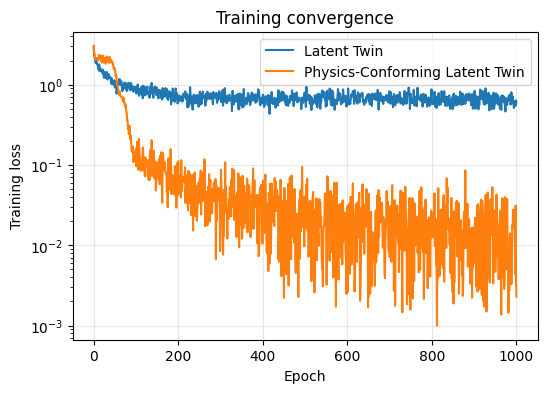

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(historyLT["total"], label="Latent Twin")
ax.plot(historyPCLT["total"], label="Physics-Conforming Latent Twin")

ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Training convergence")
ax.set_yscale("log")   # optional but usually helpful
ax.legend()
ax.grid(alpha=0.3)

plt.show()


### Conformity loss components (Physics-Conforming Latent Twin)

The Physics-Conforming Latent Twin is trained with two conformity terms
switched on simultaneously: the decoder-pullback loss
$\mathcal L_{\mathrm{pullback}}$ and the latent conformity loss
$\mathcal L_{\mathrm{latent}}$. It is instructive to track these two
components separately, in addition to the total loss shown above, to see
that both are successfully driven down during training.


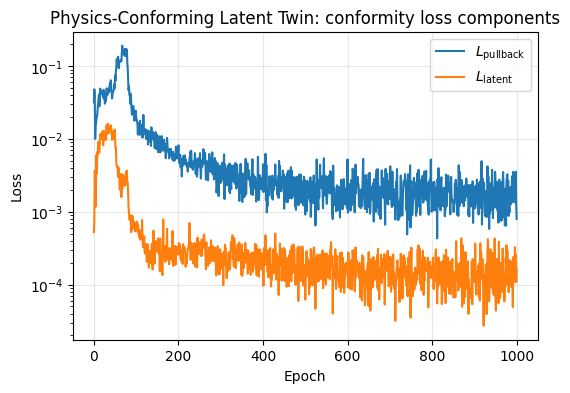

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(historyPCLT["pullback"], label=r"$L_{\mathrm{pullback}}$")
ax.plot(historyPCLT["latent"], label=r"$L_{\mathrm{latent}}$")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Physics-Conforming Latent Twin: conformity loss components")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


## 6. Evaluation: extrapolation and energy drift

The main question is whether the learned dynamics remain accurate beyond the training interval.
Both models see plenty of training pairs $t \le T_{\text{end}}$, but what happens when we rullout into
$t \in (T_{\text{end}}, T_{\text{ext}}]$, where no training pairs were ever sampled.

For each model we roll out $z_t = \exp\bigl((t - 0)W\bigr) z_0$ from the
true initial state across the *entire* time grid $t \in [0,T_{\text{ext}}]$ , decode it back to $(\theta, \omega)$, and compare against
the true trajectory. 


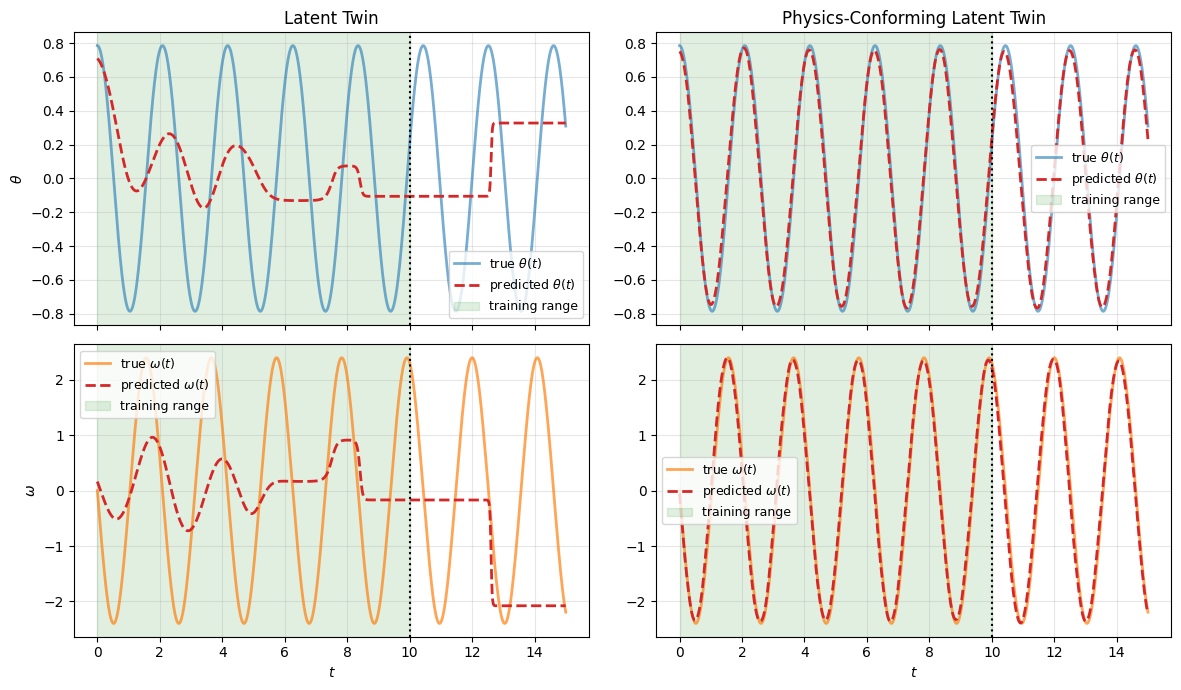

  LT | train MAE(theta) = 4.531e-01   extrap MAE(theta) = 5.289e-01
PCLT | train MAE(theta) = 4.075e-02   extrap MAE(theta) = 4.682e-02


In [27]:
def predict(model, x0, T):
    with torch.no_grad():
        z0 = model.e(x0.unsqueeze(0)).repeat(len(T), 1)
        Z = matrixExpFlow(model.W, z0, torch.zeros_like(T), T)
        return model.d(Z)


XpredLT = predict(modelLT, X[0], T)
XpredPCLT = predict(modelPCLT, X[0], T)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex="col")

for ax, Xpred, title in zip(axes[0], [XpredLT, XpredPCLT],
                            ["Latent Twin", "Physics-Conforming Latent Twin"]):
    ax.plot(T, X[:, 0], color="tab:blue", lw=2, alpha=0.6, label=r"true $\theta(t)$")
    ax.plot(T, Xpred[:, 0], "--", color="tab:red", lw=2, label=r"predicted $\theta(t)$")
    ax.axvspan(0, tEnd, color="green", alpha=0.12, label="training range")
    ax.axvline(tEnd, color="k", ls=":", lw=1.5)
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel(r"$\theta$")
for ax, Xpred in zip(axes[1], [XpredLT, XpredPCLT]):
    ax.plot(T, X[:, 1], color="tab:orange", lw=2, alpha=0.7, label=r"true $\omega(t)$")
    ax.plot(T, Xpred[:, 1], "--", color="tab:red", lw=2, label=r"predicted $\omega(t)$")
    ax.axvspan(0, tEnd, color="green", alpha=0.12, label="training range")
    ax.axvline(tEnd, color="k", ls=":", lw=1.5)
    ax.set_xlabel("$t$"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[1, 0].set_ylabel(r"$\omega$")

plt.tight_layout(); plt.show()

idxTrain, idxExtrap = (T <= tEnd).numpy(), (T > tEnd).numpy()
for name, Xpred in [("LT", XpredLT), ("PCLT", XpredPCLT)]:
    thetaErr = (Xpred[:, 0] - X[:, 0]).abs().numpy()
    print(f"{name:>4s} | train MAE(theta) = {thetaErr[idxTrain].mean():.3e}"
          f"   extrap MAE(theta) = {thetaErr[idxExtrap].mean():.3e}")


### Latent dynamics $z(t)$

It is also instructive to look directly at the latent coordinates
$z(t) = m_{\theta,0\to t}(e_\theta(x_0))$ that each model evolves
internally, *before* decoding back to $(\theta,\omega)$. If the conformity
regularizers (decoder-pullback and latent conformity) are effective, the
latent trajectory should remain more stable over long time horizons. For
the plain Latent Twin, nothing prevents the free generator $W$ from
producing latent trajectories that grow, decay, or oscillate with the
wrong frequency once we step outside the training window.


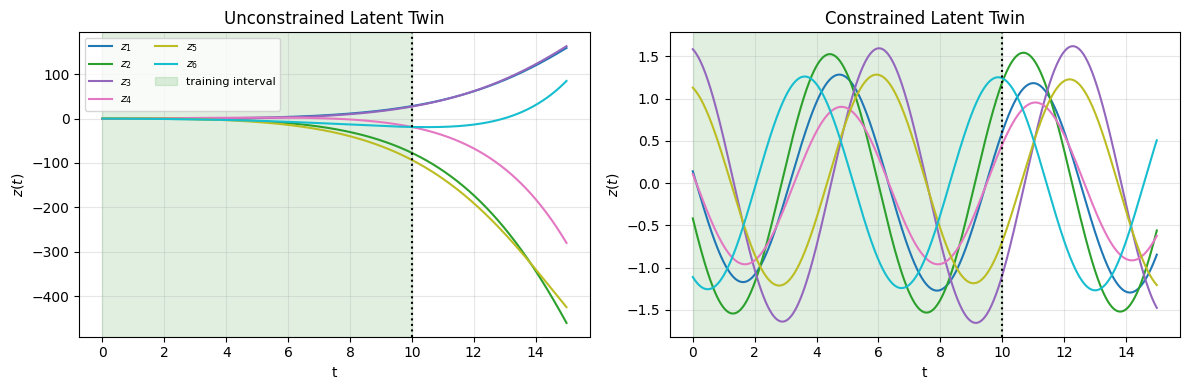

In [15]:
def predictLatent(model, x0, T):
    with torch.no_grad():
        z0 = model.e(x0.unsqueeze(0)).repeat(len(T), 1)
        return matrixExpFlow(model.W, z0, torch.zeros_like(T), T)

# Latent trajectories
Z_LT = predictLatent(modelLT, X[0], T)
Z_PCLT = predictLatent(modelPCLT, X[0], T)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # independent y-axes

colors = plt.cm.tab10(np.linspace(0, 1, Z_LT.shape[1]))

for ax, Z, title in zip(
    axes,
    [Z_LT, Z_PCLT],
    ["Latent Twin", "Physics-Conforming Latent Twin"],
):
    for k in range(Z.shape[1]):
        ax.plot(T, Z[:, k], color=colors[k], lw=1.5,
                label=rf"$z_{{{k+1}}}$")

    ax.axvspan(0, tEnd, color="green", alpha=0.12,
               label="training interval")
    ax.axvline(tEnd, color="k", ls=":", lw=1.5)

    ax.set_xlabel("t")
    ax.set_ylabel(r"$z(t)$")
    ax.set_title(title)
    ax.grid(alpha=0.3)

    # Let each subplot choose its own scale
    zmin, zmax = Z.min(), Z.max()
    pad = 0.05 * (zmax - zmin)
    ax.set_ylim(zmin - pad, zmax + pad)

axes[0].legend(fontsize=8, ncol=2, loc="upper left")

plt.tight_layout()
plt.show()


### Conformity Test

A key motivation for the conformity regularizers is to encourage the
learned dynamics to respect the pendulum's conserved energy: the
decoder-pullback loss aligns the latent energy surrogate with the decoded
physical energy, while the latent conformity loss directly penalizes any
change of the latent energy under the learned flow. To assess the combined
effect, we track both the physical energy
$
H(t)=H(\theta(t),\omega(t))
$
of the decoded trajectory and the latent energy
$
C_Z(t)=\tfrac12\|z(t)\|^2.
$

For easier comparison, we normalize the physical energy by the true Hamiltonian and the latent energy by its initial value. Under perfect conservation, both quantities remain equal to 1. Deviations from 1 indicate energy drift and provide a measure of how well the learned dynamics preserve the underlying conservation law.


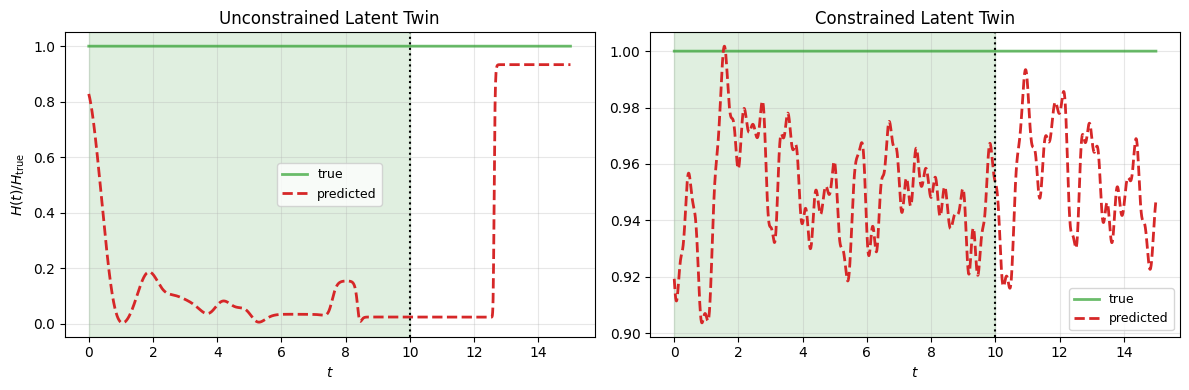

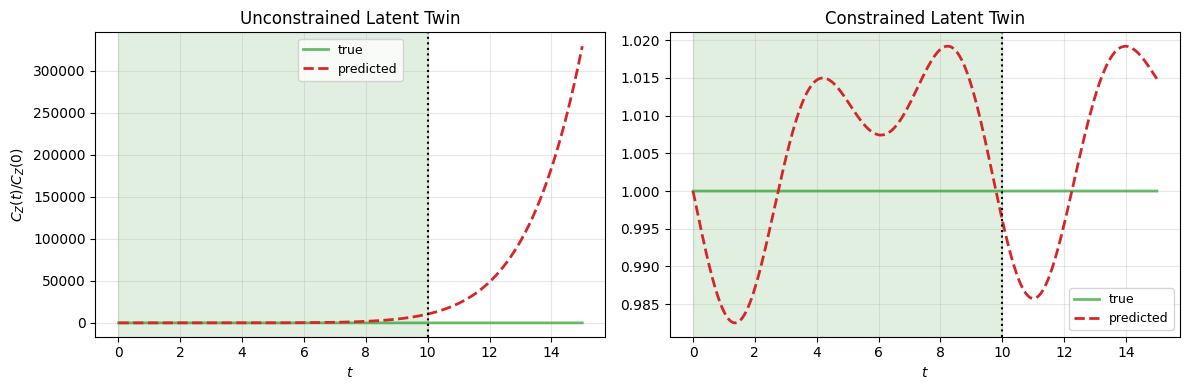

In [16]:
with torch.no_grad():
    Htrue = physicalEnergy(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, Xpred, title in zip(
    axes,
    [XpredLT, XpredPCLT],
    ["Latent Twin", "Physics-Conforming Latent Twin"]
):
    with torch.no_grad():
        Hpred = physicalEnergy(Xpred)
        H_frac = Hpred / Htrue

    ax.plot(T, torch.ones_like(T), color="tab:green", lw=2, alpha=0.7,
            label=r"true")
    ax.plot(T, H_frac, "--", color="tab:red", lw=2,
            label=r"predicted")

    ax.axvspan(0, tEnd, color="green", alpha=0.12)
    ax.axvline(tEnd, color="k", ls=":", lw=1.5)

    ax.set_title(title)
    ax.set_xlabel("$t$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel(r"$H(t)/H_\mathrm{true}$")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, Xpred, title in zip(
    axes,
    [Z_LT, Z_PCLT],
    ["Latent Twin", "Physics-Conforming Latent Twin"]
):
    with torch.no_grad():
        CZ = latentEnergy(Xpred)
        CZ_frac = CZ / CZ[0]

    ax.plot(T, torch.ones_like(T), color="tab:green", lw=2, alpha=0.7,
            label=r"true")
    ax.plot(T, CZ_frac, "--", color="tab:red", lw=2,
            label=r"predicted")

    ax.axvspan(0, tEnd, color="green", alpha=0.12)
    ax.axvline(tEnd, color="k", ls=":", lw=1.5)

    ax.set_title(title)
    ax.set_xlabel("$t$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel(r"$C_Z(t)/C_Z(0)$")

plt.tight_layout()
plt.show()


### Takeaway
This example highlights the main motivation for incorporating physics-based constraints into the training process. While both models are trained on the same data, the Physics-Conforming Latent Twin -- which combines the decoder-pullback loss with the latent conformity loss -- recovers the pendulum dynamics substantially better both within and beyond the training interval. The plain Latent Twin initially tracks the true trajectory for a short time, but its latent dynamics become unstable, leading to large drift in both latent and physical energy. As a result, prediction errors accumulate rapidly and the model quickly loses track of the true dynamics during extrapolation. In contrast, the Physics-Conforming Latent Twin is trained so that its latent energy surrogate both matches the decoded physical energy (pullback) and stays constant along the latent flow (latent conformity); together these promote stable latent trajectories and help maintain both small prediction errors and nearly constant energy over much longer time horizons.
